In [118]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
# Read dataset

df = pd.read_csv("cardiac arrest.csv")

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [76]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [77]:
df.shape

(1025, 14)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [88]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [89]:
# Check missing values

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [90]:
# Check duplicate rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [91]:
# Remove duplicate rows

df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (302, 14)


In [92]:
# Target Variable

print(df["target"].value_counts())

target
1    164
0    138
Name: count, dtype: int64


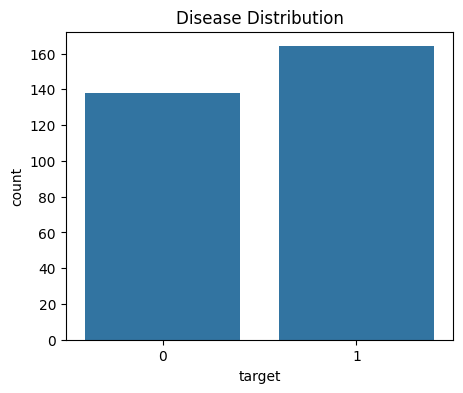

In [93]:
# Disease Distribution
plt.figure(figsize=(5,4))

sns.countplot(x="target", data=df)

plt.title("Disease Distribution")

plt.show()

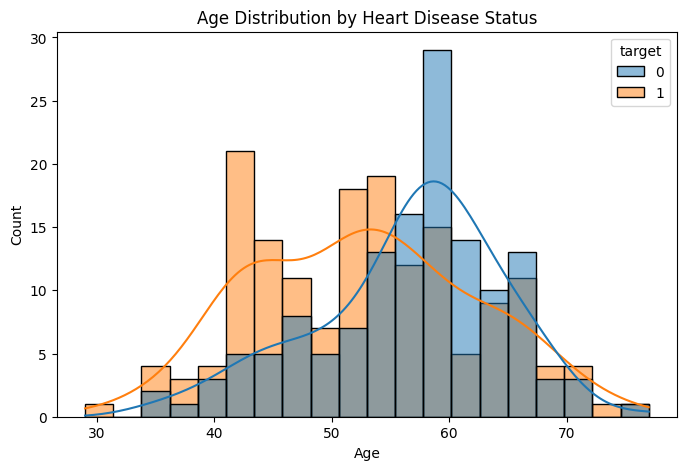

In [101]:
# Age distribution by target
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='target', kde=True, bins=20)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.show()

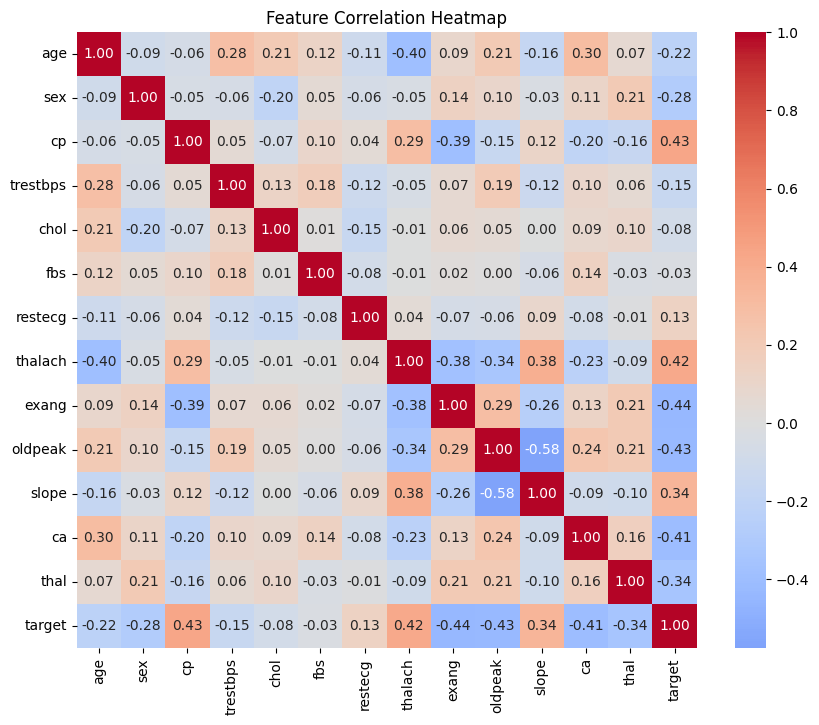

In [94]:
# # Correlation
plt.figure(figsize=(10,8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [95]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (302, 13)
Target shape: (302,)


In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.20,random_state=42)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (241, 13)
Testing Data : (61, 13)


In [97]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling done!
X_train_scaled shape: (241, 13)
X_test_scaled shape: (61, 13)


In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# 1. Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# 2. XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

# 3. Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
print("All model trained")

All model trained


In [104]:
# Calculate metrics for each model
models_predictions = {
    'Random Forest': (y_pred_rf, y_proba_rf),
    'XGBoost': (y_pred_xgb, y_proba_xgb),
    'Logistic Regression': (y_pred_lr, y_proba_lr)
}

results = {} # Initialize the dictionary
for model_name, (y_pred, y_proba) in models_predictions.items():
    results[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

# Convert to DataFrame for easy comparison
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print("Model Comparison:")
print("="*50)
print(results_df)
print("\nBest Model (by F1-Score):", results_df['F1-Score'].idxmax())
print("Best Model (by ROC-AUC):", results_df['ROC-AUC'].idxmax())

Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          0.8361     0.7879  0.8966    0.8387   0.8788
XGBoost                0.8033     0.7576  0.8621    0.8065   0.8524
Logistic Regression    0.7705     0.7027  0.8966    0.7879   0.8341

Best Model (by F1-Score): Random Forest
Best Model (by ROC-AUC): Random Forest


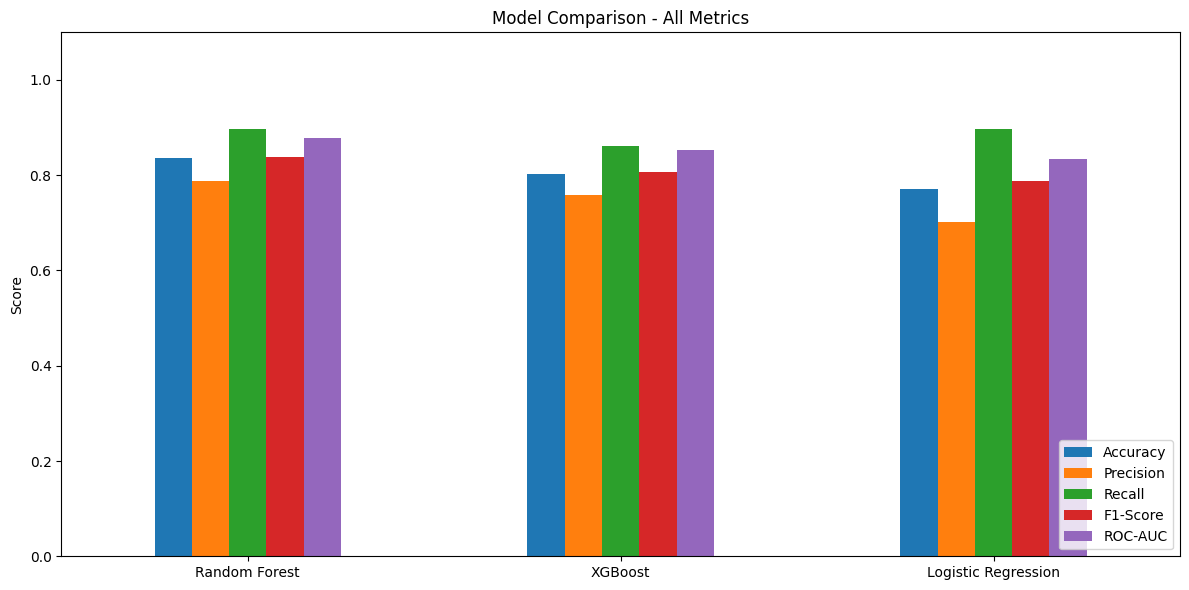

In [105]:
# Visualize comparison
results_df.plot(kind='bar', figsize=(12,6))
plt.title('Model Comparison - All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

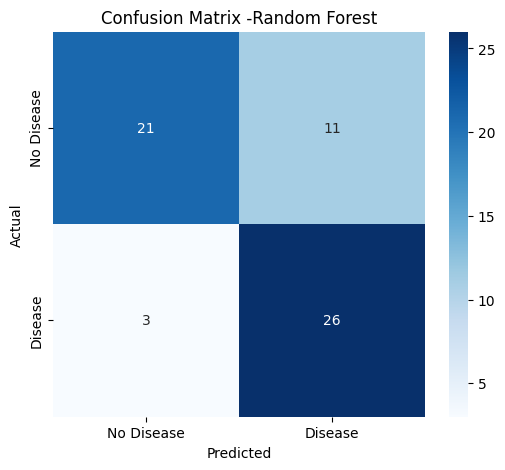

In [107]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix for Random Forest (best model)
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix -Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [108]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61



In [117]:
import joblib

# Save the trained Logistic Random Forest
joblib.dump(rf, "random_forest.pkl")

# Save the scaler (needed to transform new user input the same way)
joblib.dump(scaler, 'heart_disease_scaler.pkl')

# Save the column order (important for correct feature alignment in the app)
joblib.dump(list(X.columns), 'heart_disease_columns.pkl')

print("Model, scaler, and columns saved successfully!")

Model, scaler, and columns saved successfully!
